## Q1: Basic Exploration
* Load the dataset and check its shape, data types, and first 10 rows.

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
df = pd.read_csv('bank-full.csv', sep = ';')
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


## Q2: Missing Values Check
* Are there any missing values? Show the count per column.

In [99]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

## Q3: Summary Statistics
* Get the mean, median, and standard deviation of the age and balance columns.

In [101]:
age_mean = df['age'].mean()
age_median = df['age'].median()
age_std = df['age'].std()

print(age_mean)
print(age_median)
print(age_std)

balance_mean= df['balance'].mean()
balance_median = df['balance'].median()
balance_std = df['balance'].std()

print('\n')
print(balance_mean)
print(balance_median)
print(balance_std)

40.93621021432837
39.0
10.618762040975431


1362.2720576850766
448.0
3044.7658291686002


## Q4: Value Counts
* Find the top 5 most common jobs (job column) and their counts.

In [103]:
top_5_jobs = df['job'].value_counts().reset_index(name = 'count').sort_values(by = 'count', ascending = False).head(5)
top_5_jobs

,job,count
0,blue-collar,9732
1,management,9458
2,technician,7597
3,admin.,5171
4,services,4154


## Q5: GroupBy Analysis
* Compute the average balance grouped by marital status (marital).

In [105]:
avg_balance_by_marital = df.groupby('marital')['balance'].mean().reset_index(name = 'avg_balance')
avg_balance_by_marital

,marital,avg_balance
0,divorced,1178.872287
1,married,1425.925590
2,single,1301.497654


## Q6: Boolean Filtering
* Select clients who are students and have a balance greater than 2000.

In [107]:
filtered_df = df[(df['job'] == 'student') & (df['balance'] > 2000)]
filtered_df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1718,22,student,single,secondary,no,2412,yes,no,unknown,9,may,238,2,-1,0,unknown,no
3026,26,student,single,secondary,no,3096,yes,no,unknown,14,may,107,1,-1,0,unknown,no
6055,28,student,single,secondary,no,4716,yes,no,unknown,26,may,329,2,-1,0,unknown,no
6241,28,student,single,secondary,no,4793,no,no,unknown,27,may,151,1,-1,0,unknown,no
6508,26,student,single,secondary,no,2784,yes,no,unknown,27,may,264,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44823,20,student,single,unknown,no,2785,no,no,cellular,16,sep,327,2,-1,0,unknown,yes
44827,31,student,single,tertiary,no,4951,no,no,cellular,17,sep,285,3,81,3,failure,yes
44931,31,student,single,secondary,no,3511,no,no,cellular,6,oct,311,1,96,1,success,yes
45148,22,student,single,secondary,no,2488,no,no,cellular,8,nov,449,2,38,10,other,yes


## Q7: Cross Tabulation
* Create a cross-tab between education and y (subscription result).

In [109]:
cross_tab_df = pd.crosstab(df['education'], df['y'])
cross_tab_df

y,no,yes
education,,
primary,6260,591
secondary,20752,2450
tertiary,11305,1996
unknown,1605,252


## Q8: Encoding Prep
* Convert the categorical variable marital into dummy variables (one-hot encoding).

In [111]:
marital_dummies = pd.get_dummies(df['marital'], prefix = 'marital', dtype=int)
marital_dummies 

,marital_divorced,marital_married,marital_single
0,0,1,0
1,0,0,1
2,0,1,0
3,0,1,0
4,0,0,1
...,...,...,...
45206,0,1,0
45207,1,0,0
45208,0,1,0
45209,0,1,0


In [112]:
df_encoded = pd.concat([df, marital_dummies], axis = 1)
df_encoded.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,marital_divorced,marital_married,marital_single
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,1,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,0,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0,1,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0,1,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0,0,1


## Q9: Feature Engineering
* Create a new column balance_category:

* "Low" if balance < 0

* "Medium" if balance between 0–1500

* "High" if balance > 1500

In [114]:
df['balance_category'] = pd.cut(df['balance'], bins = [-float('inf'), 0, 1500, float('inf')],
      labels = ['Low', 'Medium', 'High'])

df[['balance_category']].head()

,balance_category
0,High
1,Medium
2,Medium
3,High
4,Medium


## Q10: Visualization
* Plot the distribution of client age using a histogram.

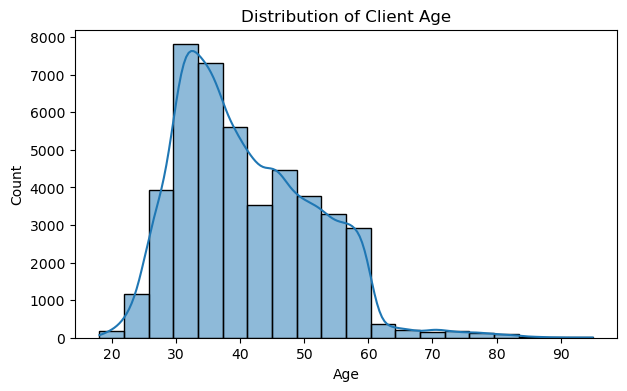

In [116]:
plt.figure(figsize = (7,4))
sns.histplot(df_encoded['age'], bins=20, kde=True)
plt.title("Distribution of Client Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()